Base score: 63.3580 | valid=True
Running 3 SAT-from-scratch attempts of 30.0s each...
----------------------------------------------------------------------------------------------------
Attempt 01 | changes=9 | first=10 rule=1 r:8->2 | impact=n=9 sources=['10', '3', '6', '7', '8'] | src=10(4) tgt=8 r:8->2 add=0 rem=4 sample=[(1, 5), (1, 14), (10, 5), (10, 14)] || src=7(0) tgt=3 no-impact-data || src=3(6) tgt=1 r:3->0 add=0 rem=74 sample=[(2, 7), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)] || ...(+6) | raw=267.988 | final=2.864 | valid=True | sanitized=True | accepted=False | selected=84 | solve=36.4s | status=FEASIBLE
Attempt 02 | changes=9 | first=5 rule=1 r:5->2 | impact=n=9 sources=['10', '3', '4', '5', '6', '8', '9'] | src=5(1) tgt=4 r:5->2 add=0 rem=47 sample=[(3, 3), (3, 12), (3, 13), (5, 0), (5, 1), (5, 2)] || src=9(0) tgt=7 no-impact-data || src=10(4) tgt=10 r:6->44 add=0 rem=0 sample=[(1, 0), (1, 9), (10, 0), (10, 9)] || ...(+6) | raw=39.975 | final=39.975 | valid=False | sanitiz

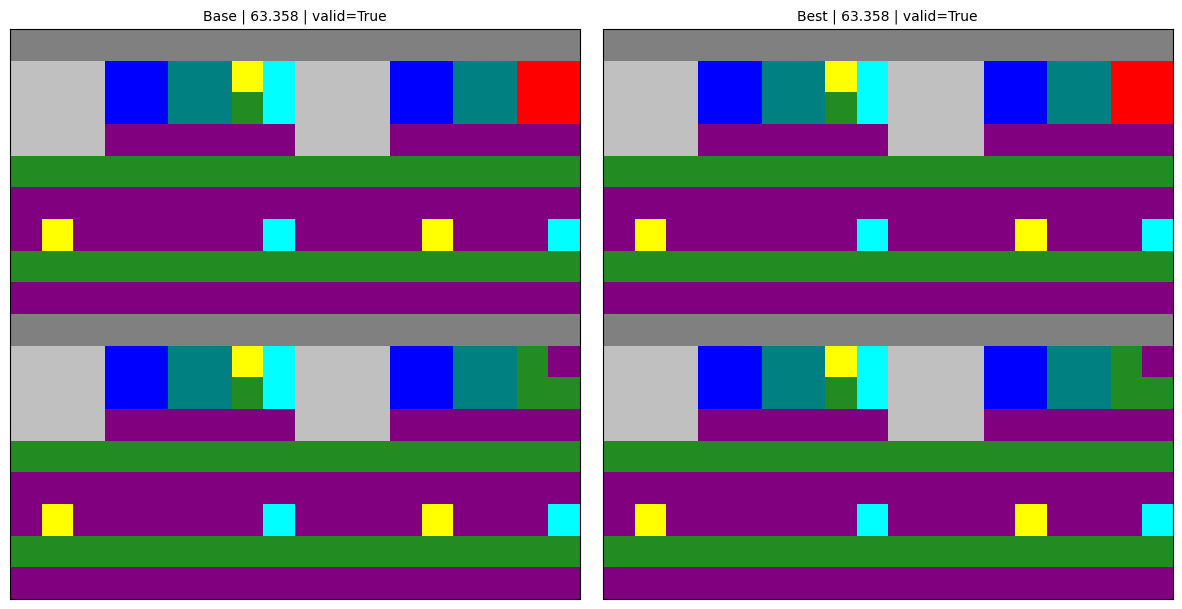

In [1]:
from collections import Counter, defaultdict, deque
import copy
import itertools
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from numba import njit
from ortools.sat.python import cp_model

pattern_image = [['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C'], ['10', '10', '10', '6', '6', '8', '8', '3', 'I8', '10', '10', '10', '6', '6', '8', '8', '5', '5'], ['10', '10', '10', '6', '6', '8', '8', '1', 'I8', '10', '10', '10', '6', '6', '8', '8', '5', '5'], ['10', '10', '10', '4', '4', '4', '4', '4', '4', '10', '10', '10', '4', '4', '4', '4', '4', '4'], ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1'], ['4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4'], ['4', '3', '4', '4', '4', '4', '4', '4', 'I8', '4', '4', '4', '4', '3', '4', '4', '4', 'I8'], ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1'], ['4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4'], ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C'], ['10', '10', '10', '6', '6', '8', '8', '3', 'I8', '10', '10', '10', '6', '6', '8', '8', '1', '4'], ['10', '10', '10', '6', '6', '8', '8', '1', 'I8', '10', '10', '10', '6', '6', '8', '8', '1', '1'], ['10', '10', '10', '4', '4', '4', '4', '4', '4', '10', '10', '10', '4', '4', '4', '4', '4', '4'], ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1'], ['4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4'], ['4', '3', '4', '4', '4', '4', '4', '4', 'I8', '4', '4', '4', '4', '3', '4', '4', '4', 'I8'], ['1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1'], ['4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4', '4']]

color_map = {'1': '#228B22', '10': '#C0C0C0', '3': '#FFFF00', '4': '#800080', '5': '#FF0000', '6': '#0000FF', '8': '#008080', 'C': '#808080', 'I8': '#00FFFF'}

TYPE_DEFS = {'CS': {'size': (1, 1), 'prod': 0, 'rules': [], 'self_imp': []}, 'C': {'size': (1, 1), 'prod': 0, 'rules': [], 'self_imp': []}, '1': {'size': (1, 1), 'prod': 14, 'rules': [{'r': 5, 't': 'C', 'min': 1}], 'self_imp': [{'cond': {'t': '2', 'min': 1, 'r': 2}, 'prod': 16}]}, '2': {'size': (1, 1), 'prod': 0, 'rules': [{'r': 5, 't': 'C', 'min': 1}], 'self_imp': []}, '3': {'size': (1, 1), 'prod': 100, 'rules': [{'r': 5, 't': '3', 'max': 0}, {'r': 3, 't': '1', 'min': 12}, {'r': 3, 't': 'C', 'min': 1}], 'self_imp': []}, '4': {'size': (1, 1), 'prod': 50, 'rules': [{'r': 1, 't': '4', 'max': 5}, {'r': 1, 't': '1', 'min': 3}], 'self_imp': []}, '5': {'size': (2, 2), 'prod': 200, 'rules': [{'r': 8, 't': '5', 'max': 0}, {'r': 5, 't': '4', 'min': 4}], 'self_imp': []}, '6': {'size': (2, 2), 'prod': 200, 'rules': [{'r': 6, 't': '6', 'max': 0}, {'r': 6, 't': '3', 'min': 2}, {'r': 3, 't': 'C', 'min': 1}], 'self_imp': [{'cond': {'t': 'I8', 'min': 6, 'r': 4}, 'prod': 400}]}, '7': {'size': (1, 1), 'prod': 32, 'rules': [{'r': 6, 't': '8', 'max': 0}, {'r': 6, 't': 'I8', 'max': 0}, {'r': 6, 't': '3', 'min': 1}, {'r': 5, 't': 'C', 'min': 1}], 'self_imp': []}, '8': {'size': (2, 2), 'prod': 700, 'rules': [{'r': 6, 't': '8', 'max': 0}, {'r': 4, 't': '1', 'min': 20}, {'r': 1, 't': 'C', 'min': 1}], 'self_imp': []}, 'I8': {'size': (1, 1), 'prod': 0, 'rules': [{'r': 3, 't': 'C', 'min': 1}], 'self_imp': []}, '9': {'size': (2, 2), 'prod': 1800, 'rules': [{'r': 6, 't': '9', 'max': 0}, {'r': 6, 't': '7', 'min': 50}, {'r': 3, 't': 'C', 'min': 1}], 'self_imp': []}, '10': {'size': (3, 3), 'prod': 2000, 'rules': [{'r': 6, 't': '10', 'max': 0}, {'r': 8, 't': '8', 'min': 3}, {'r': 3, 't': 'C', 'min': 1}], 'self_imp': []}}

TYPE_COLORS = dict(color_map)

ROAD_TYPES = {'C', 'CS'}

VIOLATION_PENALTY = 1000.0

def mod(n, m):
    return (n % m + m) % m

def clone_pattern(pattern):
    return [list(row) for row in pattern]

def footprint_cells(anchor_r, anchor_c, size, H, W):
    h, w = size
    return [(mod(anchor_r + dr, H), mod(anchor_c + dc, W)) for dr in range(h) for dc in range(w)]

def neighbors4(r, c, H, W):
    return [((r - 1) % H, c), ((r + 1) % H, c), (r, (c - 1) % W), (r, (c + 1) % W)]

def build_palette(*patterns):
    seen = []
    for pattern in patterns:
        for row in pattern:
            for cell in row:
                if cell not in seen:
                    seen.append(cell)
    ordered = [t for t in TYPE_COLORS.keys() if t in seen]
    ordered.extend([t for t in seen if t not in TYPE_COLORS])
    return ordered

def build_layout(reference_pattern):
    reference = clone_pattern(reference_pattern)
    H, W = (len(reference), len(reference[0]))
    buildings = []
    buildings_by_type = defaultdict(list)
    building_by_anchor = {}
    cell_to_building = {}
    seen = set()
    for r in range(H):
        for c in range(W):
            t = reference[r][c]
            if t not in TYPE_DEFS:
                continue
            size = TYPE_DEFS[t]['size']
            cells = footprint_cells(r, c, size, H, W)
            if all((reference[rr][cc] == t for rr, cc in cells)):
                key = (r, c, t)
                if key in seen:
                    continue
                seen.add(key)
                building = {'type': t, 'anchor': (r, c), 'size': size, 'cells': cells, 'prod_base': TYPE_DEFS[t]['prod']}
                buildings.append(building)
                buildings_by_type[t].append(building)
                building_by_anchor[r, c] = building
                for cell in cells:
                    cell_to_building[cell] = building
    road_seed_rows = [r for r in range(H) if all((reference[r][c] in ROAD_TYPES for c in range(W)))]
    road_seed_cells = {(r, c) for r in road_seed_rows for c in range(W) if reference[r][c] in ROAD_TYPES}
    if not road_seed_cells and any((reference[r][c] == 'CS' for r in range(H) for c in range(W))):
        road_seed_cells = {(r, c) for r in range(H) for c in range(W) if reference[r][c] == 'CS' and c == 0}
    if not road_seed_cells:
        road_seed_cells = {(0, c) for c in range(W) if reference[0][c] in ROAD_TYPES}
    road_cells = {(r, c) for r in range(H) for c in range(W) if reference[r][c] in ROAD_TYPES}
    return {'H': H, 'W': W, 'reference': reference, 'buildings': buildings, 'buildings_by_type': buildings_by_type, 'building_by_anchor': building_by_anchor, 'cell_to_building': cell_to_building, 'road_cells': road_cells, 'road_seed_rows': road_seed_rows, 'road_seed_cells': road_seed_cells}

def toroidal_distance(a, b, H, W, metric='chebyshev'):
    dr = abs(a[0] - b[0])
    dc = abs(a[1] - b[1])
    dr = min(dr, H - dr)
    dc = min(dc, W - dc)
    if metric == 'manhattan':
        return dr + dc
    return max(dr, dc)

def footprint_distance(cells_a, cells_b, H, W, metric='chebyshev'):
    best = None
    for a in cells_a:
        for b in cells_b:
            d = toroidal_distance(a, b, H, W, metric=metric)
            if best is None or d < best:
                best = d
                if best == 0:
                    return 0
    return best if best is not None else 999999

def compute_road_connectivity(pattern, layout):
    H, W = (layout['H'], layout['W'])
    current_road_cells = {cell for cell in layout['road_cells'] if pattern[cell[0]][cell[1]] in ROAD_TYPES}
    seed_cells = {cell for cell in layout['road_seed_cells'] if pattern[cell[0]][cell[1]] in ROAD_TYPES}
    if not seed_cells and current_road_cells:
        seed_rows = layout['road_seed_rows'] or [0]
        seed_cells = {(r, c) for r in seed_rows for c in range(W) if pattern[r][c] in ROAD_TYPES}
    connected = set(seed_cells)
    queue = deque(seed_cells)
    while queue:
        r, c = queue.popleft()
        for nr, nc in neighbors4(r, c, H, W):
            if (nr, nc) in current_road_cells and (nr, nc) not in connected:
                connected.add((nr, nc))
                queue.append((nr, nc))
    return (connected, current_road_cells, seed_cells)

def count_nearby_alive_buildings(source_building, target_type, layout, alive_anchors, radius, metric='chebyshev'):
    source_anchor = source_building['anchor']
    source_cells = source_building['cells']
    H, W = (layout['H'], layout['W'])
    count = 0
    for candidate in layout['buildings_by_type'].get(target_type, []):
        if candidate['anchor'] == source_anchor:
            continue
        if candidate['anchor'] not in alive_anchors:
            continue
        if footprint_distance(source_cells, candidate['cells'], H, W, metric=metric) <= radius:
            count += 1
    return count

def evaluate_against_layout(pattern, layout, type_defs=None):
    type_defs = type_defs or TYPE_DEFS
    H, W = (layout['H'], layout['W'])
    connected_road_cells, current_road_cells, seed_cells = compute_road_connectivity(pattern, layout)
    alive_anchors = {b['anchor'] for b in layout['buildings'] if all((pattern[r][c] == b['type'] for r, c in b['cells']))}
    violations = []
    violation_map = Counter()
    building_scores = []
    active_synergy_cells = []
    total_prod = 0
    for building in layout['buildings']:
        t = building['type']
        anchor = building['anchor']
        cells = building['cells']
        td = type_defs.get(t)
        if td is None:
            continue
        intact = anchor in alive_anchors
        if not intact:
            violations.append({'anchor': anchor, 'type': t, 'reason': 'footprint broken'})
            violation_map[anchor, t] += 1
            continue
        if t == 'CS' and anchor[1] != 0:
            violations.append({'anchor': anchor, 'type': t, 'reason': 'CS only allowed in column 1'})
            violation_map[anchor, t] += 1
        if t == 'C' and anchor not in connected_road_cells:
            violations.append({'anchor': anchor, 'type': t, 'reason': 'road not connected to a seed road'})
            violation_map[anchor, t] += 1
        building_valid = True
        for rule in td['rules']:
            count = count_nearby_alive_buildings(building, rule['t'], layout, alive_anchors, radius=rule['r'], metric=rule.get('dist', 'chebyshev'))
            if 'min' in rule and count < rule['min'] or ('max' in rule and count > rule['max']):
                building_valid = False
                violations.append({'anchor': anchor, 'type': t, 'reason': f"rule failed vs {rule['t']} at r={rule['r']} (count={count})"})
                violation_map[anchor, t] += 1
        prod = td['prod']
        for imp in td.get('self_imp', []):
            cond = imp['cond']
            count = count_nearby_alive_buildings(building, cond['t'], layout, alive_anchors, radius=cond['r'], metric=cond.get('dist', 'chebyshev'))
            if count >= cond['min']:
                prod = imp['prod']
                active_synergy_cells.extend(cells)
                break
        total_prod += prod
        building_scores.append({'anchor': anchor, 'type': t, 'size': building['size'], 'prod': prod, 'alive': True, 'valid': building_valid, 'cells': cells})
    score = total_prod / (H * W)
    valid = len(violations) == 0
    return {'valid': valid, 'violations': violations, 'violation_map': violation_map, 'upgrades': active_synergy_cells, 'score': score, 'objective': score - VIOLATION_PENALTY * len(violations), 'buildings': building_scores, 'alive_anchors': alive_anchors, 'connected_road_cells': connected_road_cells, 'seed_cells': seed_cells, 'road_cells': current_road_cells}

def summarize_eval(label, ev):
    print(f"{label:<12} | score={ev['score']:.4f} | obj={ev['objective']:.2f} | valid={ev['valid']} | violations={len(ev['violations'])}")

def plot_pattern_panel(ax, pattern, title, palette=None):
    palette = palette or build_palette(pattern)
    palette = [t for t in palette if t is not None]
    if not palette:
        palette = ['C']
    type_to_idx = {t: i for i, t in enumerate(palette)}
    fallback = 0
    grid = np.array([[type_to_idx.get(cell, fallback) for cell in row] for row in pattern])
    colors = [TYPE_COLORS.get(t, '#111111') for t in palette]
    cmap = mcolors.ListedColormap(colors)
    ax.imshow(grid, cmap=cmap, interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

def plot_story(base_pattern, corrupted_pattern, repaired_pattern, base_eval, corrupted_eval, repaired_eval):
    palette = build_palette(base_pattern, corrupted_pattern, repaired_pattern)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    plot_pattern_panel(axes[0], base_pattern, f"Base | score={base_eval['score']:.3f} | valid={base_eval['valid']} | v={len(base_eval['violations'])}", palette)
    plot_pattern_panel(axes[1], corrupted_pattern, f"Corrupto | score={corrupted_eval['score']:.3f} | valid={corrupted_eval['valid']} | v={len(corrupted_eval['violations'])}", palette)
    plot_pattern_panel(axes[2], repaired_pattern, f"Reparado | score={repaired_eval['score']:.3f} | valid={repaired_eval['valid']} | v={len(repaired_eval['violations'])}", palette)
    plt.tight_layout()
    plt.show()


SAT_TIME_LIMIT_S = 30.0

SAT_CANDIDATE_LIMIT = 120

SAT_EXTRA_RANDOM_CANDIDATES = 24

SAT_SCORE_GATE_MARGIN = 0.0

show_final_plot = False

def clone_type_defs_local(type_defs=None):
    return copy.deepcopy(type_defs or TYPE_DEFS)

RADIUS_CHOICES = [1, 2, 3, 5, 8, 10, 20]

def mutate_rule_spec_local(rule, rng, allow_annihilation=True):
    out = copy.deepcopy(rule)
    if allow_annihilation and rng.random() < 0.3:
        return None
    if 'min' in out:
        action = rng.choice(['relax', 'tighten', 'widen', 'shrink'])
        if action == 'relax':
            out['min'] = 0 if rng.random() < 0.8 else 1
        elif action == 'tighten':
            out['min'] = max(1, out['min'] + rng.choice([1, 2]))
        elif action == 'widen':
            out['r'] = rng.choice(RADIUS_CHOICES)
        else:
            out['r'] = rng.choice(RADIUS_CHOICES[:4])
    if 'max' in out:
        action = rng.choice(['relax', 'tighten', 'widen', 'shrink'])
        if action == 'relax':
            out['max'] = 9999
        elif action == 'tighten':
            out['max'] = 0
        elif action == 'widen':
            out['r'] = rng.choice(RADIUS_CHOICES)
        else:
            out['r'] = rng.choice(RADIUS_CHOICES[:4])
    return out

def mutate_self_imp_spec_local(imp, rng, allow_annihilation=True):
    out = copy.deepcopy(imp)
    if allow_annihilation and rng.random() < 0.25:
        return None
    cond = copy.deepcopy(out.get('cond', {}))
    action = rng.choice(['relax', 'tighten', 'widen', 'shrink'])
    if action == 'relax':
        cond['min'] = 0 if rng.random() < 0.8 else 1
    elif action == 'tighten':
        cond['min'] = max(1, cond['min'] + rng.choice([1, 2]))
    elif action == 'widen':
        cond['r'] = rng.choice(RADIUS_CHOICES)
    else:
        cond['r'] = rng.choice(RADIUS_CHOICES[:4])
    out['cond'] = cond
    return out

def build_road_backbone(pattern):
    return [[cell if cell in ROAD_TYPES else '.' for cell in row] for row in pattern]

def select_anchor_candidates(backbone, seed=0, limit=SAT_CANDIDATE_LIMIT, extra_random=SAT_EXTRA_RANDOM_CANDIDATES):
    rng = random.Random(seed)
    H, W = (len(backbone), len(backbone[0]))
    road_cells = [(r, c) for r in range(H) for c in range(W) if backbone[r][c] in ROAD_TYPES]
    empty_cells = [(r, c) for r in range(H) for c in range(W) if backbone[r][c] not in ROAD_TYPES]
    scored = []
    for cell in empty_cells:
        if road_cells:
            road_dist = min((toroidal_distance(cell, road, H, W, metric='chebyshev') for road in road_cells))
            road_support = sum((1 for road in road_cells if toroidal_distance(cell, road, H, W, metric='chebyshev') <= 3))
        else:
            road_dist = max(H, W)
            road_support = 0
        room = sum((1 for other in empty_cells if toroidal_distance(cell, other, H, W, metric='chebyshev') <= 2))
        score = room * 1.5 + road_support * 4.0 - road_dist * 2.0
        scored.append((score, cell))
    scored.sort(key=lambda item: item[0], reverse=True)
    chosen = [cell for _, cell in scored[:limit]]
    if len(scored) > limit:
        pool = [cell for _, cell in scored[limit:]]
        chosen.extend(rng.sample(pool, k=min(extra_random, len(pool))))
    return chosen

def mutate_type_defs_for_synthesis(type_defs=None, seed=0):
    rng = random.Random(seed)
    mutated = clone_type_defs_local(type_defs)
    changes = []
    mutable_types = [t for t, td in mutated.items() if t not in ROAD_TYPES and (td.get('rules') or td.get('self_imp'))]
    if not mutable_types:
        return (mutated, changes)
    target_count = min(len(mutable_types), rng.randint(2, min(5, len(mutable_types))))
    chosen_types = rng.sample(mutable_types, k=target_count)
    for t in chosen_types:
        td = mutated[t]
        original_rules = copy.deepcopy(td.get('rules', []))
        original_self = copy.deepcopy(td.get('self_imp', []))
        if original_rules and rng.random() < 0.35:
            td['rules'] = []
            changes.append({'type': t, 'kind': 'all_rules_annulled', 'removed': len(original_rules)})
        else:
            new_rules = []
            for rule in original_rules:
                if rng.random() < 0.75:
                    mutated_rule = mutate_rule_spec_local(rule, rng, allow_annihilation=True)
                    if mutated_rule is None:
                        changes.append({'type': t, 'kind': 'rule_annulled', 'before': rule})
                        continue
                    if mutated_rule != rule:
                        changes.append({'type': t, 'kind': 'rule_mutated', 'before': rule, 'after': mutated_rule})
                    new_rules.append(mutated_rule)
                else:
                    new_rules.append(rule)
            td['rules'] = new_rules
        if original_self and rng.random() < 0.45:
            td['self_imp'] = []
            changes.append({'type': t, 'kind': 'all_self_imp_annulled', 'removed': len(original_self)})
        else:
            new_self = []
            for imp in original_self:
                if rng.random() < 0.8:
                    mutated_imp = mutate_self_imp_spec_local(imp, rng, allow_annihilation=True)
                    if mutated_imp is None:
                        changes.append({'type': t, 'kind': 'self_imp_annulled', 'before': imp})
                        continue
                    if mutated_imp != imp:
                        changes.append({'type': t, 'kind': 'self_imp_mutated', 'before': imp, 'after': mutated_imp})
                    new_self.append(mutated_imp)
                else:
                    new_self.append(imp)
            td['self_imp'] = new_self
    return (mutated, changes)

def build_sat_synthesis_model(backbone, type_defs, seed=0, candidate_limit=SAT_CANDIDATE_LIMIT, extra_random=SAT_EXTRA_RANDOM_CANDIDATES):
    H, W = (len(backbone), len(backbone[0]))
    candidate_anchors = select_anchor_candidates(backbone, seed=seed, limit=candidate_limit, extra_random=extra_random)
    road_cells = [(r, c) for r in range(H) for c in range(W) if backbone[r][c] in ROAD_TYPES]
    placements = []
    for t, td in type_defs.items():
        if t in ROAD_TYPES:
            continue
        size = td['size']
        for anchor in candidate_anchors:
            cells = footprint_cells(anchor[0], anchor[1], size, H, W)
            if any((backbone[r][c] in ROAD_TYPES for r, c in cells)):
                continue
            placements.append({'type': t, 'anchor': anchor, 'size': size, 'cells': cells, 'prod_base': td['prod'], 'rules': copy.deepcopy(td.get('rules', [])), 'self_imp': copy.deepcopy(td.get('self_imp', []))})
    model = cp_model.CpModel()
    x = []
    for idx, placement in enumerate(placements):
        x.append(model.NewBoolVar(f"x_{placement['type']}_{placement['anchor'][0]}_{placement['anchor'][1]}_{idx}"))
    cover_map = defaultdict(list)
    for idx, placement in enumerate(placements):
        for cell in placement['cells']:
            cover_map[cell].append(idx)
    for cell, covering in cover_map.items():
        model.Add(sum((x[idx] for idx in covering)) <= 1)
    placements_by_type = defaultdict(list)
    for idx, placement in enumerate(placements):
        placements_by_type[placement['type']].append(idx)
    prod_vars = []
    for idx, placement in enumerate(placements):
        t = placement['type']
        td = type_defs[t]
        prod_var = model.NewIntVar(0, max(td['prod'], 1) * 2 + 5000, f'prod_{idx}')
        if not td.get('self_imp'):
            model.Add(prod_var == 0).OnlyEnforceIf(x[idx].Not())
            model.Add(prod_var == td['prod']).OnlyEnforceIf(x[idx])
        else:
            imp = td['self_imp'][0]
            cond = imp['cond']
            target_type = cond['t']
            metric = cond.get('dist', 'chebyshev')
            nearby = []
            for jdx in placements_by_type.get(target_type, []):
                if jdx == idx:
                    continue
                if footprint_distance(placement['cells'], placements[jdx]['cells'], H, W, metric=metric) <= cond['r']:
                    nearby.append(x[jdx])
            count_expr = model.NewConstant(0)
            if nearby:
                count_expr = sum(nearby)
            if target_type in ROAD_TYPES:
                road_hits = sum((1 for cell in road_cells if footprint_distance(placement['cells'], [cell], H, W, metric=metric) <= cond['r']))
                count_expr += road_hits
            cond_met = model.NewBoolVar(f'cond_{idx}')
            model.Add(cond_met <= x[idx])
            model.Add(count_expr >= cond['min']).OnlyEnforceIf([x[idx], cond_met])
            model.Add(count_expr <= cond['min'] - 1).OnlyEnforceIf([x[idx], cond_met.Not()])
            model.Add(prod_var == 0).OnlyEnforceIf(x[idx].Not())
            model.Add(prod_var == td['prod']).OnlyEnforceIf([x[idx], cond_met.Not()])
            model.Add(prod_var == imp['prod']).OnlyEnforceIf([x[idx], cond_met])
        prod_vars.append(prod_var)
        for rule in placement['rules']:
            target_type = rule['t']
            metric = rule.get('dist', 'chebyshev')
            nearby = []
            for jdx in placements_by_type.get(target_type, []):
                if jdx == idx:
                    continue
                if footprint_distance(placement['cells'], placements[jdx]['cells'], H, W, metric=metric) <= rule['r']:
                    nearby.append(x[jdx])
            count_expr = model.NewConstant(0)
            if nearby:
                count_expr = sum(nearby)
            if target_type in ROAD_TYPES:
                road_hits = sum((1 for cell in road_cells if footprint_distance(placement['cells'], [cell], H, W, metric=metric) <= rule['r']))
                count_expr += road_hits
            if 'min' in rule:
                model.Add(count_expr >= rule['min']).OnlyEnforceIf(x[idx])
            if 'max' in rule:
                model.Add(count_expr <= rule['max']).OnlyEnforceIf(x[idx])
    model.Maximize(sum(prod_vars))
    return (model, placements, x, candidate_anchors)

def solve_sat_from_scratch_v1(base_pattern, type_defs, seed=0, time_limit_s=SAT_TIME_LIMIT_S):
    backbone = build_road_backbone(base_pattern)
    model, placements, x, candidate_anchors = build_sat_synthesis_model(backbone, type_defs, seed=seed)
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = float(time_limit_s)
    solver.parameters.num_search_workers = max(1, (os.cpu_count() or 4) // 2)
    solver.parameters.random_seed = seed
    solver.parameters.log_search_progress = False
    status = solver.Solve(model)
    status_name = solver.StatusName(status)
    pattern = clone_pattern(backbone)
    selected = []
    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        for idx, placement in enumerate(placements):
            if solver.Value(x[idx]):
                selected.append(placement)
                for r, c in placement['cells']:
                    pattern[r][c] = placement['type']
    layout = build_layout(pattern)
    evaluation = evaluate_against_layout(pattern, layout)
    return (pattern, {'status': status_name, 'objective': solver.ObjectiveValue() if status in (cp_model.OPTIMAL, cp_model.FEASIBLE) else None, 'selected_count': len(selected), 'selected_types': Counter((p['type'] for p in selected)), 'candidate_count': len(candidate_anchors), 'placement_count': len(placements), 'evaluation': evaluation, 'selected_placements': selected, 'backbone': backbone})

def sanitize_sat_pattern_v1(pattern, backbone, max_passes=3):
    working = clone_pattern(pattern)
    steps = []
    for pass_idx in range(max_passes):
        layout = build_layout(working)
        ev = evaluate_against_layout(working, layout)
        if ev['valid']:
            break
        invalid_cells = set()
        for violation in ev['violations']:
            anchor = violation['anchor']
            building = layout['building_by_anchor'].get(anchor)
            if building is None:
                continue
            invalid_cells.update(building['cells'])
        if not invalid_cells:
            break
        for r, c in invalid_cells:
            if backbone[r][c] in ROAD_TYPES:
                continue
            working[r][c] = '.'
        steps.append({'pass': pass_idx + 1, 'pruned_cells': len(invalid_cells)})
    layout = build_layout(working)
    ev = evaluate_against_layout(working, layout)
    return (working, {'evaluation': ev, 'steps': steps})

base_pattern = clone_pattern(pattern_image)

base_layout = build_layout(base_pattern)

base_eval = evaluate_against_layout(base_pattern, base_layout)

seed = 20260404

mutated_type_defs, rule_changes = mutate_type_defs_for_synthesis(TYPE_DEFS, seed=seed)

sat_pattern, sat_info = solve_sat_from_scratch_v1(base_pattern, mutated_type_defs, seed=seed, time_limit_s=SAT_TIME_LIMIT_S)

sat_eval = sat_info['evaluation']

should_sanitize = sat_eval['score'] > base_eval['score'] + SAT_SCORE_GATE_MARGIN

sanitized_pattern = None

sanitized_info = None

accepted = False

best_pattern = clone_pattern(base_pattern)

best_eval = base_eval

SINGLE_ATTEMPTS = 3
SINGLE_TIME_LIMIT_S = 30.0
SINGLE_SCORE_GATE_MARGIN = 0.0
SINGLE_SHOW_FINAL_PLOT = True
SINGLE_SEED_BASE = 20260405


def count_pattern_differences_local(a, b):
    if len(a) != len(b) or len(a[0]) != len(b[0]):
        raise ValueError('Patterns must have the same shape')
    diff = []
    for r in range(len(a)):
        for c in range(len(a[0])):
            if a[r][c] != b[r][c]:
                diff.append((r, c, a[r][c], b[r][c]))
    return diff





def mutate_single_rule_type_defs_v1(type_defs, seed=0):
    rng = random.Random(seed)
    mutated = copy.deepcopy(type_defs)
    candidates = []

    for t, td in mutated.items():
        if t in ROAD_TYPES:
            continue
        for ridx, rule in enumerate(td.get('rules', [])):
            if rule.get('t') == 'C':
                continue
            if 'min' in rule or 'max' in rule:
                candidates.append((t, ridx, rule))

    if not candidates:
        return mutated, {'changes': [], 'target': None, 'count': 0}

    mutation_count = rng.randint(1, min(10, len(candidates)))
    selected = rng.sample(candidates, mutation_count)
    changes = []

    for target_type, rule_index, rule in selected:
        rule_kind = 'min' if 'min' in rule else 'max'
        source_t = rule.get('t')

        if rule_kind == 'min':
            field = 'r' if 'r' in rule and rng.random() < 0.80 else 'min'
        else:
            field = 'r' if 'r' in rule and rng.random() < 0.80 else 'max'

        before = rule[field]
        if field == 'min':
            # Relax the minimum by moving anywhere between 0 and the current value.
            after = rng.randint(0, before) if before > 0 else 0
        elif field == 'max':
            # Relax the maximum by moving anywhere between the current value and 50.
            after = rng.randint(before, 50)
        else:
            # Radius mutates more aggressively but still respects the rule kind.
            if rule_kind == 'min':
                lo = 0
                hi = max(before, 1)
                after = rng.randint(lo, hi)
            else:
                lo = min(before, 50)
                hi = 50
                after = rng.randint(lo, hi)
            if after == before:
                pool = [r for r in range(0, 51) if r != before]
                after = rng.choice(pool) if pool else before

        if after == before:
            if field == 'min' and before > 0:
                after = rng.randint(0, before - 1) if before > 1 else 0
            elif field == 'max' and before < 50:
                after = rng.randint(before + 1, 50)
            elif field == 'r':
                pool = [r for r in range(0, 51) if r != before]
                after = rng.choice(pool) if pool else before

        rule[field] = after
        changes.append({
            'type': target_type,
            'rule_index': rule_index,
            'rule_kind': rule_kind,
            'field': field,
            'before': before,
            'after': after,
            'source_t': source_t,
        })

    return mutated, {
        'changes': changes,
        'target': (changes[0]['type'], changes[0]['rule_index'], changes[0]['field']) if changes else None,
        'count': len(changes),
    }


def describe_rule_impact(base_layout, change, mutated_type_defs, sample_limit=6):
    source_type = change['type']
    rule = mutated_type_defs[source_type]['rules'][change['rule_index']]
    target_type = rule.get('t')
    source_buildings = [b for b in base_layout['buildings'] if b['type'] == source_type]
    target_buildings = [b for b in base_layout['buildings'] if b['type'] == target_type] if target_type in TYPE_DEFS else []

    if not source_buildings or not target_buildings:
        return {
            'source_type': source_type,
            'target_type': target_type,
            'source_count': len(source_buildings),
            'target_count': len(target_buildings),
            'before_radius': change['before'] if change['field'] == 'r' else rule.get('r', 0),
            'after_radius': change['after'] if change['field'] == 'r' else rule.get('r', 0),
            'added_targets': [],
            'removed_targets': [],
            'local_targets': [],
            'summary': f'src={source_type}({len(source_buildings)}) tgt={target_type} no-impact-data',
        }

    before_radius = change['before'] if change['field'] == 'r' else rule.get('r', 0)
    after_radius = change['after'] if change['field'] == 'r' else rule.get('r', 0)
    old_targets = set()
    new_targets = set()
    local_targets = set()
    width = base_layout['W']

    for sb in source_buildings:
        for tb in target_buildings:
            d = toroidal_distance(sb['anchor'], tb['anchor'], base_layout['H'], width)
            if d <= before_radius:
                old_targets.add(tb['anchor'])
            if d <= after_radius:
                new_targets.add(tb['anchor'])
                local_targets.add(tb['anchor'])

    added_targets = sorted(new_targets - old_targets)
    removed_targets = sorted(old_targets - new_targets)
    sample = added_targets[:sample_limit] or removed_targets[:sample_limit] or sorted(local_targets)[:sample_limit]

    if change['field'] == 'r':
        summary = (
            f"src={source_type}({len(source_buildings)}) tgt={target_type} "
            f"r:{before_radius}->{after_radius} add={len(added_targets)} rem={len(removed_targets)} sample={sample}"
        )
    else:
        summary = (
            f"src={source_type}({len(source_buildings)}) tgt={target_type} "
            f"{change['field']}:{change['before']}->{change['after']} local={len(local_targets)} sample={sample}"
        )

    return {
        'source_type': source_type,
        'target_type': target_type,
        'source_count': len(source_buildings),
        'target_count': len(target_buildings),
        'before_radius': before_radius,
        'after_radius': after_radius,
        'added_targets': added_targets,
        'removed_targets': removed_targets,
        'local_targets': sorted(local_targets),
        'sample': sample,
        'summary': summary,
    }


def describe_rule_batch_impact(base_layout, changes, mutated_type_defs, sample_limit=6):
    if not changes:
        return {
            'changes': [],
            'summary': 'n=0 no-changes',
        }

    per_change = [
        describe_rule_impact(base_layout, change, mutated_type_defs, sample_limit=sample_limit)
        for change in changes
    ]
    summaries = [entry['summary'] for entry in per_change]
    unique_sources = sorted({entry['source_type'] for entry in per_change})
    summary = 'n={0} sources={1} | {2}'.format(
        len(per_change),
        unique_sources,
        ' || '.join(summaries[:3]),
    )
    if len(summaries) > 3:
        summary += ' || ...(+{0})'.format(len(summaries) - 3)

    return {
        'changes': per_change,
        'count': len(per_change),
        'sources': unique_sources,
        'summary': summary,
    }


base_pattern = clone_pattern(pattern_image)
base_layout = build_layout(base_pattern)
base_eval = evaluate_against_layout(base_pattern, base_layout)

best_pattern = clone_pattern(base_pattern)
best_eval = base_eval
best_attempt = 0
best_source = 'base'
attempt_logs = []
corrupt_calls = 0
sanitize_calls = 0
accepted = 0
total_rule_changes = 0
total_start = time.perf_counter()

print('Base score: {0:.4f} | valid={1}'.format(base_eval['score'], base_eval['valid']))
print('Running {0} SAT-from-scratch attempts of {1:.1f}s each...'.format(SINGLE_ATTEMPTS, SINGLE_TIME_LIMIT_S))
print('-' * 100)

for attempt in range(SINGLE_ATTEMPTS):
    seed = SINGLE_SEED_BASE + attempt * 137
    mutated_type_defs, mutation_info = mutate_single_rule_type_defs_v1(TYPE_DEFS, seed=seed)
    mutation_changes = mutation_info['changes']
    mutation_desc = mutation_changes[0] if mutation_changes else {'type': 'n/a', 'field': 'n/a', 'before': 'n/a', 'after': 'n/a', 'rule_index': -1}
    impact_info = describe_rule_batch_impact(base_layout, mutation_changes, mutated_type_defs, sample_limit=6)

    solve_start = time.perf_counter()
    sat_pattern, sat_info = solve_sat_from_scratch_v1(
        base_pattern,
        mutated_type_defs,
        seed=seed,
        time_limit_s=SINGLE_TIME_LIMIT_S,
    )
    solve_elapsed = time.perf_counter() - solve_start
    corrupt_calls += 1
    total_rule_changes += len(mutation_changes)

    sat_layout = build_layout(sat_pattern)
    raw_eval = evaluate_against_layout(sat_pattern, sat_layout)

    should_sanitize = raw_eval['score'] > best_eval['score'] + SINGLE_SCORE_GATE_MARGIN
    sanitized = False
    sanitize_info = {'evaluation': raw_eval, 'steps': [], 'skipped': True}
    sanitized_pattern = sat_pattern
    sanitized_eval = raw_eval

    if should_sanitize:
        sanitized_pattern, sanitize_info = sanitize_sat_pattern_v1(sat_pattern, sat_info['backbone'], max_passes=10)
        sanitized_eval = sanitize_info['evaluation']
        sanitize_calls += 1
        sanitized = True

    final_pattern = sanitized_pattern
    final_eval = sanitized_eval
    final_source = 'sanitized' if sanitized else 'raw'

    if raw_eval['valid'] and raw_eval['score'] > final_eval['score'] + 1e-9:
        final_pattern = sat_pattern
        final_eval = raw_eval
        final_source = 'raw'

    accepted_now = final_eval['valid'] and final_eval['score'] > best_eval['score'] + 1e-9
    if accepted_now:
        best_pattern = clone_pattern(final_pattern)
        best_eval = final_eval
        best_attempt = attempt + 1
        best_source = final_source
        accepted += 1

    attempt_logs.append({
        'attempt': attempt + 1,
        'seed': seed,
        'mutation': mutation_desc,
        'mutation_count': len(mutation_changes),
        'impact': impact_info,
        'raw_score': raw_eval['score'],
        'raw_valid': raw_eval['valid'],
        'sanitized': sanitized,
        'final_score': final_eval['score'],
        'final_valid': final_eval['valid'],
        'accepted': accepted_now,
        'selected': sat_info['selected_count'],
        'status': sat_info['status'],
        'solve_elapsed_s': solve_elapsed,
    })

    print(
        'Attempt {0:02d} | changes={1} | first={2} rule={3} {4}:{5}->{6} | impact={7} | raw={8:.3f} | final={9:.3f} | valid={10} | sanitized={11} | accepted={12} | selected={13} | solve={14:.1f}s | status={15}'.format(
            attempt + 1,
            len(mutation_changes),
            mutation_desc.get('type', 'n/a'),
            mutation_desc.get('rule_index', -1),
            mutation_desc.get('field', 'n/a'),
            mutation_desc.get('before', 'n/a'),
            mutation_desc.get('after', 'n/a'),
            impact_info['summary'],
            raw_eval['score'],
            final_eval['score'],
            final_eval['valid'],
            sanitized,
            accepted_now,
            sat_info['selected_count'],
            solve_elapsed,
            sat_info['status'],
        )
    )

elapsed = time.perf_counter() - total_start
best_diffs = count_pattern_differences_local(base_pattern, best_pattern)
same_as_base = len(best_diffs) == 0

print()
print('Resumen final')
summarize_eval('Base', base_eval)
summarize_eval('Best', best_eval)
print('Best attempt: {0}'.format(best_attempt))
print('Best source: {0}'.format(best_source))
print('Same as base: {0}'.format(same_as_base))
print('Different cells: {0}'.format(len(best_diffs)))
print('Elapsed total: {0:.1f}s'.format(elapsed))
print('Corrupt calls: {0}'.format(corrupt_calls))
print('Rule changes: {0}'.format(total_rule_changes))
print('Sanitize calls: {0}'.format(sanitize_calls))
print('Accepted improvements: {0}'.format(accepted))
print('Best delta vs base: {0:+.4f}'.format(best_eval['score'] - base_eval['score']))

print()
print('Ultimos intentos')
for row in attempt_logs[-5:]:
    print(
        f"  attempt={row['attempt']:02d} | changes={row.get('mutation_count', 1)} | type={row['mutation'].get('type', 'n/a')} | field={row['mutation'].get('field', 'n/a')} | raw={row['raw_score']:.3f} | final={row['final_score']:.3f} | valid={row['final_valid']} | sanitized={row['sanitized']} | accepted={row['accepted']} | solve={row['solve_elapsed_s']:.1f}s | impact={row['impact']['summary']}"
    )

if best_diffs:
    print()
    print('First differences')
    for r, c, before, after in best_diffs[:20]:
        print('  ({0}, {1}) {2} -> {3}'.format(r, c, before, after))

if SINGLE_SHOW_FINAL_PLOT:
    palette = build_palette(base_pattern, best_pattern)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    plot_pattern_panel(axes[0], base_pattern, 'Base | {0:.3f} | valid={1}'.format(base_eval['score'], base_eval['valid']), palette)
    plot_pattern_panel(axes[1], best_pattern, 'Best | {0:.3f} | valid={1}'.format(best_eval['score'], best_eval['valid']), palette)
    plt.tight_layout()
    plt.show()
